In [1]:
import kagglehub

path = kagglehub.dataset_download("robikscube/hourly-energy-consumption")
print("Dataset downloaded to:", path)

Dataset downloaded to: C:\Users\Carlos Roberto\.cache\kagglehub\datasets\robikscube\hourly-energy-consumption\versions\3


In [2]:
import os

for file in os.listdir(path):
    print(file)

AEP_hourly.csv
COMED_hourly.csv
DAYTON_hourly.csv
DEOK_hourly.csv
DOM_hourly.csv
DUQ_hourly.csv
EKPC_hourly.csv
est_hourly.paruqet
FE_hourly.csv
NI_hourly.csv
PJME_hourly.csv
PJMW_hourly.csv
pjm_hourly_est.csv
PJM_Load_hourly.csv


In [3]:
import pandas as pd

df = pd.read_csv(f"{path}/PJME_hourly.csv")
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [4]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  str    
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), str(1)
memory usage: 2.2 MB


(145366, 2)

In [5]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  145366 non-null  datetime64[us]
 1   PJME_MW   145366 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 2.2 MB


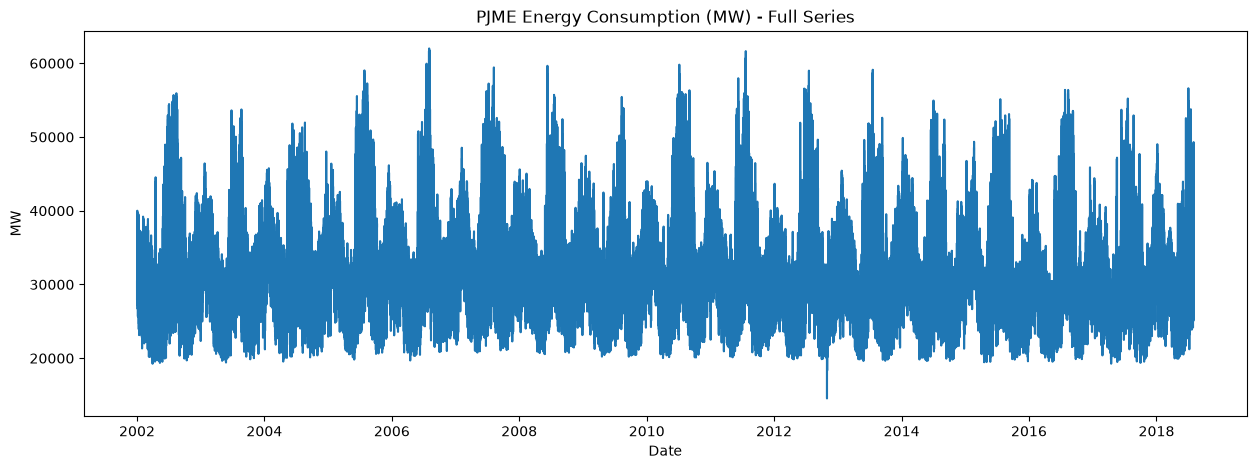

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(df['Datetime'], df['PJME_MW'])
plt.title('PJME Energy Consumption (MW) - Full Series')
plt.xlabel('Date')
plt.ylabel('MW')
plt.show()

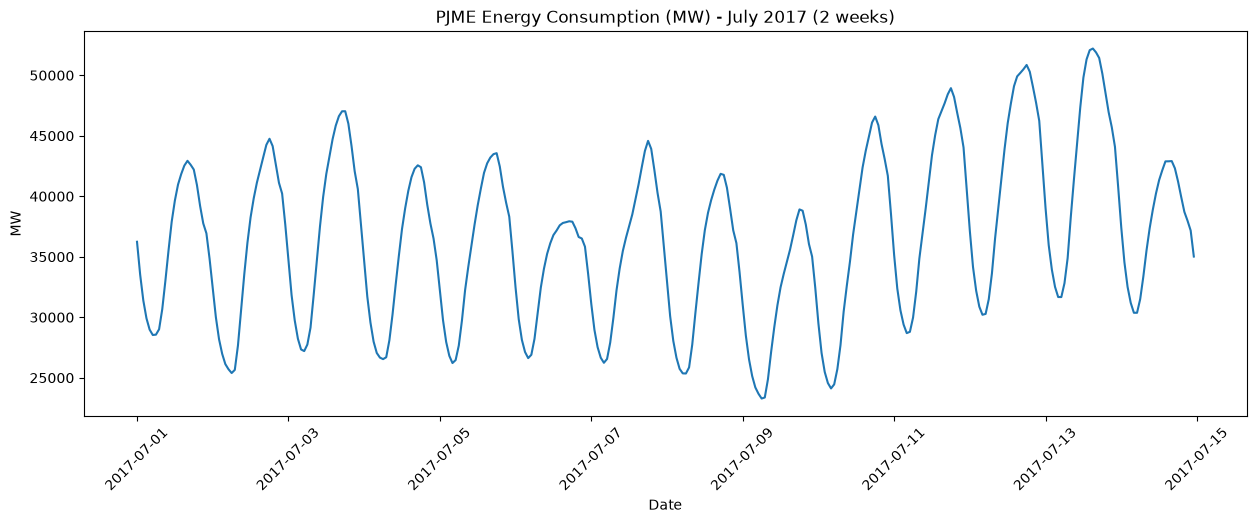

In [7]:
df_zoom = df[(df['Datetime'] >= '2017-07-01') & (df['Datetime'] < '2017-07-15')]

plt.figure(figsize=(15, 5))
plt.plot(df_zoom['Datetime'], df_zoom['PJME_MW'])
plt.title('PJME Energy Consumption (MW) - July 2017 (2 weeks)')
plt.xlabel('Date')
plt.ylabel('MW')
plt.xticks(rotation=45)
plt.show()

In [8]:
df['hour'] = df['Datetime'].dt.hour
df['day_of_week'] = df['Datetime'].dt.dayofweek  # 0 = Monday, 6 = Sunday
df['month'] = df['Datetime'].dt.month
df['year'] = df['Datetime'].dt.year

df[['Datetime', 'hour', 'day_of_week', 'month', 'year']].head()

,Datetime,hour,day_of_week,month,year
0,2002-01-01 01:00:00,1,1,1,2002
1,2002-01-01 02:00:00,2,1,1,2002
2,2002-01-01 03:00:00,3,1,1,2002
3,2002-01-01 04:00:00,4,1,1,2002
4,2002-01-01 05:00:00,5,1,1,2002


In [9]:
import numpy as np

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df[['hour', 'hour_sin', 'hour_cos']].head(3)

,hour,hour_sin,hour_cos
0,1,0.258819,0.965926
1,2,0.500000,0.866025
2,3,0.707107,0.707107


In [10]:
df['lag_1h'] = df['PJME_MW'].shift(1)
df['lag_24h'] = df['PJME_MW'].shift(24)
df['lag_168h'] = df['PJME_MW'].shift(168)

df['rolling_mean_24h'] = df['PJME_MW'].rolling(window=24).mean()

df[['Datetime', 'PJME_MW', 'lag_1h', 'lag_24h', 'lag_168h', 'rolling_mean_24h']].head(10)

,Datetime,PJME_MW,lag_1h,lag_24h,lag_168h,rolling_mean_24h
0,2002-01-01 01:00:00,30393.0,NaN,NaN,NaN,NaN
1,2002-01-01 02:00:00,29265.0,30393.0,NaN,NaN,NaN
2,2002-01-01 03:00:00,28357.0,29265.0,NaN,NaN,NaN
3,2002-01-01 04:00:00,27899.0,28357.0,NaN,NaN,NaN
4,2002-01-01 05:00:00,28057.0,27899.0,NaN,NaN,NaN
5,2002-01-01 06:00:00,28654.0,28057.0,NaN,NaN,NaN
6,2002-01-01 07:00:00,29308.0,28654.0,NaN,NaN,NaN
7,2002-01-01 08:00:00,29595.0,29308.0,NaN,NaN,NaN
8,2002-01-01 09:00:00,29943.0,29595.0,NaN,NaN,NaN
9,2002-01-01 10:00:00,30692.0,29943.0,NaN,NaN,NaN


In [11]:
print("Rows before:", df.shape[0])

df = df.dropna().reset_index(drop=True)

print("Rows after:", df.shape[0])
df.head()

Rows before: 145366
Rows after: 145198


,Datetime,PJME_MW,hour,day_of_week,month,year,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,lag_1h,lag_24h,lag_168h,rolling_mean_24h
0,2002-01-08 01:00:00,29445.0,1,1,1,2002,0.258819,0.965926,0.781831,0.62349,0.5,0.866025,31187.0,26862.0,30393.0,33560.208333
1,2002-01-08 02:00:00,28670.0,2,1,1,2002,0.500000,0.866025,0.781831,0.62349,0.5,0.866025,29445.0,25976.0,29265.0,33672.458333
2,2002-01-08 03:00:00,28375.0,3,1,1,2002,0.707107,0.707107,0.781831,0.62349,0.5,0.866025,28670.0,25641.0,28357.0,33786.375000
3,2002-01-08 04:00:00,28542.0,4,1,1,2002,0.866025,0.500000,0.781831,0.62349,0.5,0.866025,28375.0,25666.0,27899.0,33906.208333
4,2002-01-08 05:00:00,29261.0,5,1,1,2002,0.965926,0.258819,0.781831,0.62349,0.5,0.866025,28542.0,26328.0,28057.0,34028.416667


In [12]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

print("Train period:", train['Datetime'].min(), "to", train['Datetime'].max())
print("Test period:", test['Datetime'].min(), "to", test['Datetime'].max())
print("Train rows:", len(train), "| Test rows:", len(test))

Train period: 2002-01-08 01:00:00 to 2015-04-11 00:00:00
Test period: 2015-04-11 01:00:00 to 2018-08-03 00:00:00
Train rows: 116158 | Test rows: 29040


In [13]:
feature_cols = [
    'hour_sin', 'hour_cos',
    'day_of_week_sin', 'day_of_week_cos',
    'month_sin', 'month_cos',
    'lag_1h', 'lag_24h', 'lag_168h',
    'rolling_mean_24h'
]

X_train = train[feature_cols]
y_train = train['PJME_MW']

X_test = test[feature_cols]
y_test = test['PJME_MW']

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (116158, 10)
X_test shape: (29040, 10)


In [14]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MAE: {mae:.2f} MW")
print(f"RMSE: {rmse:.2f} MW")
print(f"MAPE: {mape:.2f}%")

MAE: 308.92 MW
RMSE: 417.32 MW
MAPE: 0.98%


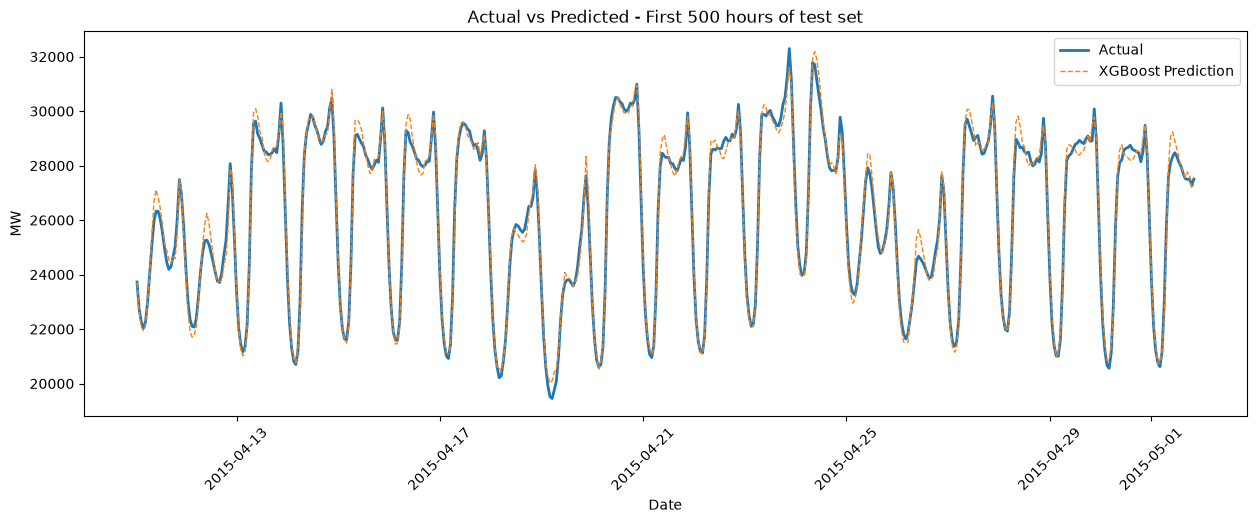

In [17]:
plt.figure(figsize=(15, 5))
plt.plot(test['Datetime'].iloc[:500], y_test.iloc[:500], label='Actual', linewidth=2)
plt.plot(test['Datetime'].iloc[:500], y_pred[:500], label='XGBoost Prediction', linewidth=1, linestyle='--')
plt.title('Actual vs Predicted - First 500 hours of test set')
plt.xlabel('Date')
plt.ylabel('MW')
plt.legend()
plt.xticks(rotation=45)
plt.show()

            feature  importance
6            lag_1h    0.943884
1          hour_cos    0.031858
0          hour_sin    0.007435
5         month_cos    0.005186
2   day_of_week_sin    0.003845
7           lag_24h    0.002458
9  rolling_mean_24h    0.002237
4         month_sin    0.001149
8          lag_168h    0.001094
3   day_of_week_cos    0.000853


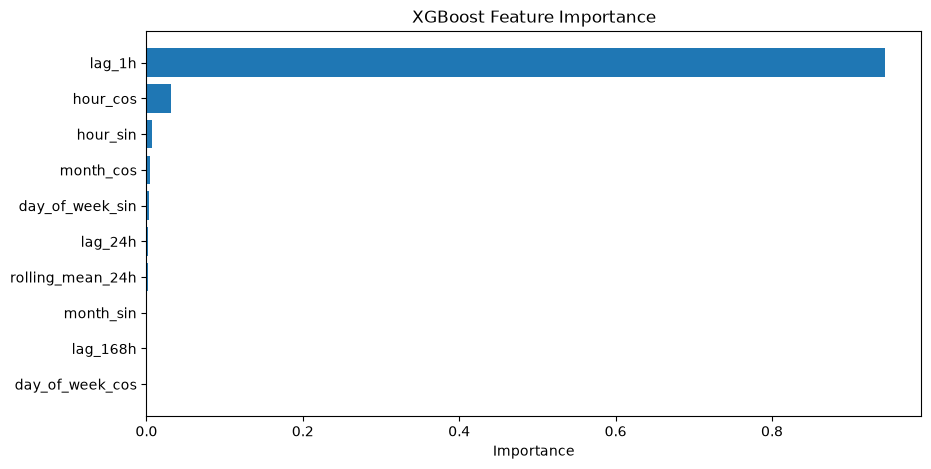

In [18]:
importances = model.feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feat_imp)

plt.figure(figsize=(10, 5))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.show()

In [19]:
feature_cols_24h = [
    'hour_sin', 'hour_cos',
    'day_of_week_sin', 'day_of_week_cos',
    'month_sin', 'month_cos',
    'lag_24h', 'lag_168h',
    'rolling_mean_24h'
]

X_train_24h = train[feature_cols_24h]
y_train_24h = train['PJME_MW']

X_test_24h = test[feature_cols_24h]
y_test_24h = test['PJME_MW']

print("Features used:", feature_cols_24h)

Features used: ['hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'lag_24h', 'lag_168h', 'rolling_mean_24h']


In [21]:
model_24h = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model_24h.fit(X_train_24h, y_train_24h)

y_pred_24h = model_24h.predict(X_test_24h)

mae_24h = mean_absolute_error(y_test_24h, y_pred_24h)
rmse_24h = np.sqrt(mean_squared_error(y_test_24h, y_pred_24h))
mape_24h = np.mean(np.abs((y_test_24h - y_pred_24h) / y_test_24h)) * 100

print("=== XGBoost - 24h-ahead forecast ===")
print(f"MAE: {mae_24h:.2f} MW")
print(f"RMSE: {rmse_24h:.2f} MW")
print(f"MAPE: {mape_24h:.2f}%")

=== XGBoost - 24h-ahead forecast ===
MAE: 1157.40 MW
RMSE: 1548.58 MW
MAPE: 3.67%


In [22]:
naive_persistence_1h = test['lag_1h']
naive_1h_mae = mean_absolute_error(y_test, naive_persistence_1h)
naive_1h_rmse = np.sqrt(mean_squared_error(y_test, naive_persistence_1h))
naive_1h_mape = np.mean(np.abs((y_test - naive_persistence_1h) / y_test)) * 100

naive_pred = test['lag_24h']
naive_mae = mean_absolute_error(y_test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))
naive_mape = np.mean(np.abs((y_test - naive_pred) / y_test)) * 100

In [24]:
comparison = pd.DataFrame({
    'Model': [
        'Naive Persistence (1h horizon)',
        'XGBoost (1h horizon, with lag_1h)',
        'Naive Seasonal (24h horizon)',
        'XGBoost (24h horizon, no lag_1h)'
    ],
    'MAE': [naive_1h_mae, mae, naive_mae, mae_24h],
    'RMSE': [naive_1h_rmse, rmse, naive_rmse, rmse_24h],
    'MAPE (%)': [naive_1h_mape, mape, naive_mape, mape_24h]
})

comparison = comparison.round(2)
comparison

,Model,MAE,RMSE,MAPE (%)
0,Naive Persistence (1h horizon),1070.05,1373.87,3.48
1,"XGBoost (1h horizon, with lag_1h)",308.92,417.32,0.98
2,Naive Seasonal (24h horizon),2184.22,3009.11,6.93
3,"XGBoost (24h horizon, no lag_1h)",1157.40,1548.58,3.67


In [25]:
import joblib

joblib.dump(model_24h, 'model_24h.pkl')
print("Model saved to model_24h.pkl")

Model saved to model_24h.pkl
